# Discrete Diffusion Baseline for Paired-Antibody Generation (OADM + ESM-2 8M)

Faithful re-implementation of the **generative baseline** from
*Zhao, Moller, Quintero-Cadena, van Niekerk — "Guided Generation for Developable Antibodies"*
(ICML 2025 GenBio Workshop, arXiv:2507.02670).

This notebook reproduces **only the unguided discrete-diffusion generative model** (Section 1.1 of the paper),
so it can serve as a baseline to compare against a Discrete Flow Matching (DFM) model you build later.
The SVDD developability guidance and the developability predictors are **deliberately left out** (you asked for
the baseline only). Hooks are noted where SVDD would attach.

---
### What the paper specifies (and what this notebook implements faithfully)

| Paper detail (§1.1) | This notebook |
|---|---|
| Masked **discrete diffusion**, **order-agnostic diffusion model (OADM)** objective (Hoogeboom 2021), as used in EvoDiff (Alamdari 2023) | ✅ exact OADM masking + ARDM ELBO reweighting `D/(D−t+1)` |
| "re-trained an **ESM-2 (8M)** architecture" (`esm2_t6_8M_UR50D`, 6 layers, dim 320) | ✅ `EsmForMaskedLM`, 8M |
| Paired heavy+light concatenated as `<heavy>\|<light>` with a **pipe token** | ✅ added pipe token to the tokenizer + resized embeddings |
| Trained on OAS paired sequences, **AntiRef-90** dedup + **MMseqs2** @ 90% | ⚙️ data hook provided; preprocessing documented (see Data section) |
| Generation: **sample a length** from the training set, decode to that length | ✅ length sampled from empirical (heavy_len, light_len) pairs |
| Decode by **minimum-entropy positions** (not random order) | ✅ implemented (random-order also available) |
| **Temperature** softmax `p(x_i)=e^{x_i/T}/Σ e^{x_j/T}` | ✅ temperature sampling |

### What is adapted for Colab (clearly flagged)
- **Data scale.** The full OAS paired set → 2.1M MMseqs2 clusters. That is not Colab-friendly to
  download/cluster here, so the notebook ships with a small built-in **smoke-test dataset** and a clean hook to plug
  in your own `heavy/light` CSV (and the real AntiRef-90 + MMseqs2 recipe is documented). The *architecture and
  algorithm* are exact; only the corpus size is a knob.
- **Warm start.** The paper says "re-trained" the ESM-2 architecture; whether that means from-scratch or fine-tuned is
  ambiguous. Default here is `INIT_FROM_PRETRAINED=True` (warm-start from ESM-2 8M weights) because it converges fast
  on Colab. Flip to `False` for from-scratch training of the same architecture.


In [1]:
# === Install dependencies (Colab) ===========================================
# transformers provides the ESM-2 8M architecture (EsmForMaskedLM) + tokenizer.
%pip -q install "transformers>=4.40" "torch>=2.1" datasets pandas numpy tqdm
# Optional (naturalness eval, mirrors the paper's AbLang2 / p-IgGen scoring) -- uncomment if wanted:
# %pip -q install ablang2 pigen
print("deps installed")

deps installed


In [2]:
# === Imports & device =======================================================
import os, json, math, random, itertools
from dataclasses import dataclass, field, asdict
from collections import Counter
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, EsmForMaskedLM, get_cosine_schedule_with_warmup
from tqdm.auto import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
def set_seed(s=0):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(0)
print("device:", DEVICE)

device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Configuration

`esm2_t6_8M_UR50D` is the 8M-parameter ESM-2 (6 layers, hidden dim 320) — the architecture the paper "re-trained".


In [4]:
@dataclass
class Config:
    # --- model (paper: ESM-2 8M architecture) ---
    model_name: str = "facebook/esm2_t6_8M_UR50D"
    init_from_pretrained: bool = True   # warm-start vs from-scratch (paper ambiguous; see header)
    pipe_token: str = "|"               # heavy|light separator (paper)
    max_length: int = 300               # paired H+L (~110-130 + ~105-115) + specials

    # --- OADM objective ---
    reweight: bool = True               # ARDM ELBO reweighting D/(D-t+1) (EvoDiff-faithful)

    # --- optimization (tune for your corpus size) ---
    batch_size: int = 32
    lr: float = 1e-4
    weight_decay: float = 0.01
    max_steps: int = 20000              # real-scale default; smoke-test runs fine at ~300 too.
                                        # 1 epoch over ~1.68M clusters @ bs32 is ~52k steps --
                                        # raise as your credits allow; checkpointing (below)
                                        # makes it safe to stop and extend later.
    warmup_steps: int = 200
    grad_clip: float = 1.0
    amp: bool = True                    # mixed precision on GPU
    log_every: int = 25
    eval_every: int = 500

    # --- checkpointing / resume (Drive-backed; survives disconnects & credit-out) ---
    ckpt_every: int = 200               # save full training state every N steps
    resume: bool = True                 # auto-resume from the latest checkpoint if one exists

    seed: int = 0

    # --- generation ---
    gen_decoding: str = "min_entropy"   # "min_entropy" (paper) or "random"
    gen_temperature: float = 1.0        # paper's favorable trade-off point
    gen_unmask_per_step: int = 1        # 1 = faithful one-token-per-step OADM; >1 = faster

cfg = Config()
print(asdict(cfg))

{'model_name': 'facebook/esm2_t6_8M_UR50D', 'init_from_pretrained': True, 'pipe_token': '|', 'max_length': 300, 'reweight': True, 'batch_size': 32, 'lr': 0.0001, 'weight_decay': 0.01, 'max_steps': 20000, 'warmup_steps': 200, 'grad_clip': 1.0, 'amp': True, 'log_every': 25, 'eval_every': 500, 'ckpt_every': 200, 'resume': True, 'seed': 0, 'gen_decoding': 'min_entropy', 'gen_temperature': 1.0, 'gen_unmask_per_step': 1}


## 2. Tokenizer (ESM-2 + pipe token)

ESM-2's tokenizer is character-level over amino acids with `<cls> ... <eos>` and a `<mask>` token (reused as the
OADM absorbing/mask state). The `|` separator is **not** in ESM's vocab, so we add it and resize the model
embeddings accordingly.


In [5]:
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
# add the heavy|light separator
if cfg.pipe_token not in tokenizer.get_vocab():
    tokenizer.add_tokens([cfg.pipe_token])

MASK_ID = tokenizer.mask_token_id
PAD_ID  = tokenizer.pad_token_id
CLS_ID  = tokenizer.cls_token_id
EOS_ID  = tokenizer.eos_token_id
PIPE_ID = tokenizer.convert_tokens_to_ids(cfg.pipe_token)

# the 20 canonical amino acids -- generation is restricted to these (no X/B/U/Z/O, no specials)
AA = list("ACDEFGHIKLMNPQRSTVWY")
AA_IDS = torch.tensor(tokenizer.convert_tokens_to_ids(AA), dtype=torch.long)

# tokens that must NEVER be masked during training (structural / special tokens)
NEVER_MASK = {CLS_ID, EOS_ID, PAD_ID, PIPE_ID}
print("vocab size:", len(tokenizer), "| mask:", MASK_ID, "pad:", PAD_ID,
      "cls:", CLS_ID, "eos:", EOS_ID, "pipe:", PIPE_ID)
print("AA ids:", AA_IDS.tolist())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:116: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

vocab size: 34 | mask: 32 pad: 1 cls: 0 eos: 2 pipe: 33
AA ids: [5, 23, 13, 9, 18, 6, 21, 12, 15, 4, 20, 17, 14, 16, 10, 8, 11, 7, 22, 19]


## 3. Data

The paper trains on **paired OAS** sequences after **AntiRef-90** filtering and **MMseqs2** clustering at 90% identity
(→ 1.68M clusters). Reproducing that at full scale is out of scope for a Colab notebook, but the pipeline is simple to
state and the model code below is agnostic to corpus size.

**To use the real corpus**, produce a table with two columns `heavy` and `light` (one paired antibody per row), then
set `DATA_CSV` below. Recommended full-scale recipe (run offline, once):

1. Download **paired** OAS units (Olsen et al. 2022) — the bulk paired CSVs from the OAS website.
2. Extract the full-length heavy (`sequence_alignment_aa`) and light amino-acid sequences per pair.
3. **AntiRef-90** (Briney 2023) to drop partial sequences, then cluster with **MMseqs2** `easy-cluster --min-seq-id 0.9`
   on the concatenated `heavy|light` string; keep one representative per cluster.
4. Save representatives as a `heavy,light` CSV.

If `DATA_CSV` is unset, the notebook falls back to a tiny **smoke-test** corpus so everything runs end-to-end. The
smoke set is *not* meaningful biology — it only exercises the code path. Replace it before drawing conclusions.


In [6]:
# === Real-data pipeline: persistent storage + knobs ==========================
# PERSISTENT (Drive, survives disconnects/credit-out): extracted pairs, clustered
# CSV, training checkpoints -- all small, fits the 10 GB account.
# EPHEMERAL (/content, ~100 GB, NOT Drive quota): raw downloads + mmseqs temp.


import os, glob, json, subprocess, pathlib

# --- persistent (Drive) ---
DRIVE_ROOT   = '/content/drive/MyDrive/2026 Spring/BMI 702/post_class_project'
EXTRACT_DIR  = os.path.join(DRIVE_ROOT, 'extracted')            # per-unit heavy,light parquet
OAS_REPR_CSV = os.path.join(DRIVE_ROOT, 'oas_paired_repr.csv')  # final clustered representatives
CKPT_DIR     = os.path.join(DRIVE_ROOT, 'checkpoints')          # resumable training state
# --- ephemeral (fast local disk) ---
SCRATCH      = '/content/scratch'
RAW_DIR      = os.path.join(SCRATCH, 'raw')                     # raw .csv.gz, deleted after use
MMSEQS_TMP   = os.path.join(SCRATCH, 'mmseqs_tmp')

for d in (DRIVE_ROOT, EXTRACT_DIR, CKPT_DIR, SCRATCH, RAW_DIR, MMSEQS_TMP):
    os.makedirs(d, exist_ok=True)

# clustering / full-length filter knobs (paper: AntiRef-90 full-length + MMseqs2 @ 0.9)
MIN_SEQ_ID  = 0.90        # MMseqs2 --min-seq-id (90% identity)
COV         = 0.80        # coverage
H_LEN_RANGE = (90, 160)   # plausible full-length heavy V-region aa length
L_LEN_RANGE = (90, 130)   # plausible full-length light V-region aa length

print('DRIVE_ROOT:', DRIVE_ROOT)
print('extracted units so far:', len(glob.glob(os.path.join(EXTRACT_DIR, '*.parquet'))))
print('representative CSV exists:', os.path.exists(OAS_REPR_CSV))

DRIVE_ROOT: /content/drive/MyDrive/2026 Spring/BMI 702/post_class_project
extracted units so far: 580
representative CSV exists: True


In [7]:
# === Stage 1: download + extract paired sequences (RESUMABLE) ================
# Skips entirely if the clustered representative CSV is already built,
# so 'Run all' never errors on a missing bulk_download.sh once you've clustered.
if os.path.exists(OAS_REPR_CSV + '.done'):
    print('Clustered representatives already built -> Stage 1 (download/extract) skipped.')
else:
    # === Stage 1: download + extract paired sequences (RESUMABLE) ================
    # Each OAS unit is processed independently: download -> extract heavy/light ->
    # write a small parquet to Drive -> DELETE the raw file. A unit whose parquet
    # already exists is SKIPPED, so re-running after a disconnect/credit-out resumes.
    import pandas as pd, re, urllib.request
    from tqdm.auto import tqdm

    def find_bulk_script():
        for p in (os.path.join(DRIVE_ROOT, 'bulk_download.sh'), '/content/bulk_download.sh'):
            if os.path.exists(p):
                return p
        return None

    def parse_urls(script_path):
        txt = pathlib.Path(script_path).read_text()
        return re.findall(r'https?://\S+\.csv\.gz', txt)

    AA_OK = set('ACDEFGHIKLMNPQRSTVWY')
    def clean(seq):
        if not isinstance(seq, str):
            return None
        s = seq.strip().upper().replace('-', '').replace('.', '').replace('*', '')
        return s if s and set(s) <= AA_OK else None

    def extract_unit(url):
        unit = re.sub(r'[^A-Za-z0-9_.-]', '_', url.rsplit('/', 1)[-1].replace('.csv.gz', ''))
        out = os.path.join(EXTRACT_DIR, unit + '.parquet')
        if os.path.exists(out):
            return unit, 'skip'
        raw = os.path.join(RAW_DIR, unit + '.csv.gz')
        try:
            urllib.request.urlretrieve(url, raw)
            # OAS paired CSV layout: line 0 = metadata JSON, line 1 = column header
            df = pd.read_csv(raw, header=1, low_memory=False)
            cols = {c.lower(): c for c in df.columns}
            hc = cols.get('sequence_alignment_aa_heavy')
            lc = cols.get('sequence_alignment_aa_light')
            if not (hc and lc):
                return unit, f'no-cols:{list(df.columns)[:6]}'
            rows = []
            for h, l in zip(df[hc], df[lc]):
                h, l = clean(h), clean(l)
                if (h and l
                        and H_LEN_RANGE[0] <= len(h) <= H_LEN_RANGE[1]
                        and L_LEN_RANGE[0] <= len(l) <= L_LEN_RANGE[1]):
                    rows.append((h, l))
            outdf = pd.DataFrame(rows, columns=['heavy', 'light']).drop_duplicates()
            outdf.to_parquet(out, index=False)   # only written on full success -> atomic-ish unit
            return unit, f'ok:{len(outdf)}'
        finally:
            if os.path.exists(raw):
                os.remove(raw)                    # free ephemeral disk immediately

    script = find_bulk_script()
    assert script, (f'Put bulk_download.sh at {DRIVE_ROOT}/bulk_download.sh -- get it from the '
                    'OAS paired download page (select Paired -> Download).')
    urls = parse_urls(script)
    print(f'{len(urls)} unit URLs found in {script}')
    for url in tqdm(urls, desc='units'):
        unit, status = extract_unit(url)
        if not status.startswith('skip'):
            tqdm.write(f'{unit}: {status}')
    print('extracted unit files on Drive:', len(glob.glob(os.path.join(EXTRACT_DIR, '*.parquet'))))


Clustered representatives already built -> Stage 1 (download/extract) skipped.


In [8]:
# === Stage 2: AntiRef-style filter + MMseqs2 clustering @ 90% (CACHED) ========
# Runs ONCE. Output cached to OAS_REPR_CSV with a .done sentinel -> re-running skips.
done_marker = OAS_REPR_CSV + ".done"
if os.path.exists(done_marker):
    reps_n = pathlib.Path(done_marker).read_text()
    print(f"representative set already built ({reps_n}) -> {OAS_REPR_CSV}")
else:
    import pandas as pd
    # 2a. concatenate all extracted units, global dedup on (heavy, light)
    parts = [pd.read_parquet(p) for p in glob.glob(os.path.join(EXTRACT_DIR, '*.parquet'))]
    assert parts, 'no extracted units found -- run Stage 1 first'
    allp = (pd.concat(parts, ignore_index=True)
              .drop_duplicates(['heavy', 'light']).reset_index(drop=True))
    print('total unique pairs before clustering:', len(allp))

    # 2b. install MMseqs2 (once per session)
    MMSEQS = '/content/mmseqs/bin/mmseqs'
    if not os.path.exists(MMSEQS):
        subprocess.run('wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz '
                       '-O /content/mmseqs.tar.gz', shell=True, check=True)
        subprocess.run('tar xzf /content/mmseqs.tar.gz -C /content', shell=True, check=True)

    # IMPORTANT: keep all scratch on LOCAL disk, never on mounted Drive
    import time, multiprocessing
    LOCAL = '/content/mmseqs_work'; os.makedirs(LOCAL, exist_ok=True)
    fasta     = os.path.join(LOCAL, 'pairs.fasta')
    pref      = os.path.join(LOCAL, 'clu')
    tmp       = os.path.join(LOCAL, 'tmp'); os.makedirs(tmp, exist_ok=True)
    nthreads  = multiprocessing.cpu_count()
    print('cpu cores:', nthreads)

    # 2c. write FASTA fast (single join, not 2.5M individual writes)
    t0 = time.time()
    with open(fasta, 'w') as f:
        f.write('\n'.join(f'>{i}\n{h}{l}'
                          for i, (h, l) in enumerate(zip(allp['heavy'], allp['light']))))
    print(f'wrote FASTA in {time.time()-t0:.0f}s')

    # 2d. LINEAR-TIME clustering (right tool for millions of seqs at high identity)
    t0 = time.time()
    cmd = (f'{MMSEQS} easy-linclust {fasta} {pref} {tmp} '
    #cmd = (f'{MMSEQS} easy-cluster {fasta} {pref} {tmp} '  # switch if enough compute
           f'--min-seq-id {MIN_SEQ_ID} -c {COV} --cov-mode 1 '
           f'--threads {nthreads} --remove-tmp-files 1 -v 3')
    print('running:', cmd, flush=True)
    proc = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in proc.stdout:           # live progress
        print(line, end='', flush=True)
    if proc.wait() != 0:
        raise RuntimeError('mmseqs easy-linclust failed')
    print(f'clustering done in {(time.time()-t0)/60:.1f} min')

    # 2e. map representatives back to (heavy, light) and cache to Drive
    rep_ids = []
    with open(pref + '_rep_seq.fasta') as f:
        for line in f:
            if line.startswith('>'):
                rep_ids.append(int(line[1:].strip()))
    reps = allp.iloc[sorted(rep_ids)].reset_index(drop=True)
    reps.to_csv(OAS_REPR_CSV, index=False)
    pathlib.Path(done_marker).write_text(f'{len(reps)} representatives')
    print(f'clustered {len(allp)} -> {len(reps)} representatives -> {OAS_REPR_CSV}')

representative set already built (2093844 representatives) -> /content/drive/MyDrive/2026 Spring/BMI 702/post_class_project/oas_paired_repr.csv


In [9]:
# ---- Load paired training data -------------------------------------------------
# Auto-wire to the MMseqs2 clustered representatives produced by the pipeline above.
# If that CSV does not exist (you skipped the pipeline), fall back to a tiny synthetic
# smoke-test corpus so the notebook still runs end-to-end with zero external data.
DATA_CSV = OAS_REPR_CSV if ('OAS_REPR_CSV' in globals() and os.path.exists(OAS_REPR_CSV)) else None

def load_pairs(csv_path):
    import pandas as pd
    df = pd.read_csv(csv_path)
    cols = {c.lower(): c for c in df.columns}
    h = cols.get("heavy") or cols.get("heavy_sequence") or cols.get("sequence_alignment_aa_heavy")
    l = cols.get("light") or cols.get("light_sequence") or cols.get("sequence_alignment_aa_light")
    assert h and l, f"need heavy/light columns, found {list(df.columns)}"
    okset = set(AA)
    pairs = [(str(a).strip().upper(), str(b).strip().upper())
             for a, b in zip(df[h], df[l]) if isinstance(a, str) and isinstance(b, str)]
    return [(a, b) for a, b in pairs if a and b and set(a) <= okset and set(b) <= okset]

def smoke_pairs(n=512, seed=0):
    # crude antibody-flavored sequences ONLY to exercise the pipeline (not real biology).
    rng = random.Random(seed)
    h_core = "QVQLVQSGAEVKKPGASVKVSCKASGYTFTSYAMSWVRQAPGQGLEWMG"
    l_core = "DIQMTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKLLIY"
    def jitter(s):
        s = list(s)
        for _ in range(rng.randint(2, 8)):
            i = rng.randrange(len(s)); s[i] = rng.choice(AA)
        cdr = "".join(rng.choice(AA) for _ in range(rng.randint(8, 16)))
        return "".join(s) + cdr + "".join(rng.choice(AA) for _ in range(rng.randint(20, 35)))
    return [(jitter(h_core), jitter(l_core)) for _ in range(n)]

# Completeness filter == the paper's "remove partial sequences" (AntiRef) step.
# Plausible full-length paired V-domain lengths; wider than typical to keep long CDR3s.
# Applied to REAL data only (smoke sequences are short by construction).
_HLEN = globals().get("H_LEN_RANGE", (90, 160))
_LLEN = globals().get("L_LEN_RANGE", (90, 130))
def _complete(h, l):
    return _HLEN[0] <= len(h) <= _HLEN[1] and _LLEN[0] <= len(l) <= _LLEN[1]

if DATA_CSV:
    pairs = load_pairs(DATA_CSV)
    before = len(pairs)
    pairs = [(h, l) for h, l in pairs if _complete(h, l)]
    print(f"loaded {before:,} real pairs from {DATA_CSV}")
    print(f"completeness filter: kept {len(pairs):,}/{before:,} "
          f"({100*len(pairs)/max(before,1):.1f}%) -- dropped partial/oversized chains")
else:
    pairs = smoke_pairs()
    print(f"[SMOKE-TEST] {len(pairs)} synthetic pairs -- run the pipeline cells above for real OAS data")

assert len(pairs) >= 10, "too few pairs after filtering -- check the data pipeline / length ranges"
random.Random(cfg.seed).shuffle(pairs)
n_val = max(1, int(0.05 * len(pairs)))
val_pairs, train_pairs = pairs[:n_val], pairs[n_val:]
print(f"train: {len(train_pairs):,}  val: {len(val_pairs):,}")


loaded 2,093,844 real pairs from /content/drive/MyDrive/2026 Spring/BMI 702/post_class_project/oas_paired_repr.csv
completeness filter: kept 2,093,844/2,093,844 (100.0%) -- dropped partial/oversized chains
train: 1,989,152  val: 104,692


In [11]:
# Empirical (heavy_len, light_len) distribution -- generation samples lengths from this (paper).
LENGTH_PAIRS = [(len(h), len(l)) for h, l in train_pairs]

def encode_pair(h, l):
    s = h + cfg.pipe_token + l
    enc = tokenizer(s, add_special_tokens=True, truncation=True,
                    max_length=cfg.max_length, return_tensors=None)
    return torch.tensor(enc["input_ids"], dtype=torch.long)

def _encode_all_cached(pairs, name):
    # cache tokenized tensors so we tokenize ONCE, then load in seconds next session.
    cache = os.path.join(globals().get("CKPT_DIR", "/content/checkpoints"),
                         f"tok_{name}_{len(pairs)}_{len(tokenizer)}_{cfg.max_length}.pt")
    if os.path.exists(cache):
        data = torch.load(cache)
        print(f"loaded {len(data)} tokenized {name} seqs from cache")
        return data
    from tqdm.auto import tqdm
    data = [encode_pair(h, l) for h, l in tqdm(pairs, desc=f"tokenizing {name}")]
    torch.save(data, cache + ".tmp"); os.replace(cache + ".tmp", cache)
    print(f"tokenized + cached {len(data)} {name} seqs -> {cache}")
    return data

class PairedAbDataset(Dataset):
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

train_ds = PairedAbDataset(_encode_all_cached(train_pairs, "train"))
val_ds   = PairedAbDataset(_encode_all_cached(val_pairs, "val"))
print("example encoded length:", len(train_ds[0]))

tokenizing train:   0%|          | 0/1989152 [00:00<?, ?it/s]

tokenized + cached 1989152 train seqs -> /content/drive/MyDrive/2026 Spring/BMI 702/post_class_project/checkpoints/tok_train_1989152_34_300.pt


tokenizing val:   0%|          | 0/104692 [00:00<?, ?it/s]

tokenized + cached 104692 val seqs -> /content/drive/MyDrive/2026 Spring/BMI 702/post_class_project/checkpoints/tok_val_104692_34_300.pt
example encoded length: 250


## 4. OADM masking collator + loss

**OADM forward process (EvoDiff / Hoogeboom 2021).** For a sequence with `D` maskable positions (amino-acid
positions only — `cls/eos/pad/|` are never masked), draw `t ~ Uniform{1,…,D}`, mask `m = D − t + 1` randomly chosen
positions to `<mask>`, and predict them. This is equivalent to choosing a random decoding order and a random cut point.

**Loss (ARDM ELBO).** Each masked-token cross-entropy is reweighted by `D / (D − t + 1) = D / m`, matching the
order-agnostic autoregressive ELBO and EvoDiff's `OAMaskedCrossEntropyLoss`. The denominator is the total number of
maskable tokens in the batch.


In [12]:
class OADMCollator:
    # Order-Agnostic Diffusion masking, EvoDiff-faithful.
    def __init__(self, mask_id, pad_id, never_mask):
        self.mask_id, self.pad_id, self.never_mask = mask_id, pad_id, set(never_mask)

    def __call__(self, batch):
        maxlen = max(x.numel() for x in batch)
        N = len(batch)
        input_ids = torch.full((N, maxlen), self.pad_id, dtype=torch.long)
        labels    = torch.full((N, maxlen), -100, dtype=torch.long)
        attn      = torch.zeros((N, maxlen), dtype=torch.long)
        timesteps = torch.zeros(N, dtype=torch.long)  # m = #masked per seq
        Ds        = torch.zeros(N, dtype=torch.long)  # #maskable per seq
        for i, seq in enumerate(batch):
            L = seq.numel()
            input_ids[i, :L] = seq
            attn[i, :L] = 1
            maskable = [p for p in range(L) if int(seq[p]) not in self.never_mask]
            D = len(maskable)
            t = random.randint(1, D)            # Uniform{1..D}
            m = D - t + 1                        # number to mask (1..D)
            chosen = random.sample(maskable, m)
            for p in chosen:
                labels[i, p] = input_ids[i, p]
                input_ids[i, p] = self.mask_id
            timesteps[i] = m
            Ds[i] = D
        return {"input_ids": input_ids, "attention_mask": attn,
                "labels": labels, "timesteps": timesteps, "Ds": Ds}

collator = OADMCollator(MASK_ID, PAD_ID, NEVER_MASK)

def oadm_loss(logits, labels, timesteps, Ds, reweight=True):
    N, L, V = logits.shape
    ce = F.cross_entropy(logits.reshape(-1, V), labels.reshape(-1),
                         reduction="none", ignore_index=-100).reshape(N, L)
    masked = (labels != -100).float()
    if reweight:
        # per-token weight = D / m  (broadcast across that sequence's masked tokens)
        w = (Ds.float() / timesteps.float().clamp(min=1)).unsqueeze(1)   # (N,1)
        num = (ce * masked * w).sum()
        den = Ds.float().sum().clamp(min=1)
    else:
        num = (ce * masked).sum()
        den = masked.sum().clamp(min=1)
    return num / den

# quick shape sanity
_b = collator([train_ds[i] for i in range(min(4, len(train_ds)))])
print({k: tuple(v.shape) for k, v in _b.items()})


{'input_ids': (4, 250), 'attention_mask': (4, 250), 'labels': (4, 250), 'timesteps': (4,), 'Ds': (4,)}


## 5. Model

`EsmForMaskedLM` instantiates the ESM-2 8M architecture and its MLM head, which is exactly what OADM needs (predict the
identity of masked tokens). We resize the embedding table to make room for the `|` token.


In [13]:
if cfg.init_from_pretrained:
    model = EsmForMaskedLM.from_pretrained(cfg.model_name)
else:
    from transformers import EsmConfig
    model = EsmForMaskedLM(EsmConfig.from_pretrained(cfg.model_name))  # same architecture, random init

model.resize_token_embeddings(len(tokenizer))

# --- ESM LM-head bias fix ---------------------------------------------------
# resize_token_embeddings resizes the decoder weight + tied input embeddings,
# but ESM's EsmLMHead keeps a SEPARATE `bias` Parameter that it does NOT resize.
# After adding '|', decoder outputs len(tokenizer) logits while lm_head.bias is
# still the old length -> shape mismatch in `self.decoder(x) + self.bias`.
V = len(tokenizer)
old_bias = model.lm_head.bias.data
if old_bias.numel() != V:
    new_bias = torch.zeros(V, dtype=old_bias.dtype, device=old_bias.device)
    new_bias[:old_bias.numel()] = old_bias            # keep learned biases, new token -> 0
    model.lm_head.bias = torch.nn.Parameter(new_bias)
model.config.vocab_size = V

model.to(DEVICE)
assert model.lm_head.bias.numel() == model.lm_head.decoder.weight.shape[0] == V, "vocab/bias mismatch"
n_params = sum(p.numel() for p in model.parameters())
print(f"model params: {n_params/1e6:.1f}M  | vocab: {V} | init_from_pretrained={cfg.init_from_pretrained}")

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


model params: 7.5M  | vocab: 34 | init_from_pretrained=True


## 6. Training loop

In [15]:
# --- guard: clear message instead of a bare NameError if setup did not run ---
_need = ["model", "train_ds", "val_ds", "collator", "oadm_loss", "cfg"]
_missing = [n for n in _need if n not in globals()]
assert not _missing, ("Run the setup cells first (Runtime > Run all, or Run before). "
                      f"Missing: {_missing}")

def make_loader(ds, shuffle):
    return DataLoader(ds, batch_size=cfg.batch_size, shuffle=shuffle,
                      collate_fn=collator, drop_last=shuffle)

@torch.no_grad()
def evaluate(model, loader, max_batches=20):
    model.eval(); tot, nb = 0.0, 0
    for b in itertools.islice(loader, max_batches):
        b = {k: v.to(DEVICE) for k, v in b.items()}
        logits = model(input_ids=b["input_ids"], attention_mask=b["attention_mask"]).logits
        tot += oadm_loss(logits, b["labels"], b["timesteps"], b["Ds"], cfg.reweight).item(); nb += 1
    model.train()
    return tot / max(nb, 1)

# ===========================================================================
# Checkpointing + lightweight metric logging, designed for a LIMITED Drive.
#   * Full training state -> LOCAL disk (/content) every ckpt_every steps.
#     Local is free (~100 GB, off your Drive quota) and uses os.replace, which is a
#     true in-place rename on a normal filesystem (no Trash).
#   * Mirrored to Drive only SPARSELY and IN PLACE via shutil.copyfile (NOT os.replace).
#     os.replace over the Drive FUSE mount = delete-to-Trash + rename, which is what
#     filled your Trash with dozens of 86 MB copies. copyfile overwrites the single
#     existing Drive file in place, so Drive keeps ~one checkpoint, not a pile.
#   * metrics.csv: one tiny row per eval (step, train_loss, val_loss, lr) -> a few KB
#     even for a long run. This is the downsampled loss history you plot afterwards.
# ===========================================================================
import shutil, csv
LOCAL_CKPT_DIR = "/content/ckpt_local"; os.makedirs(LOCAL_CKPT_DIR, exist_ok=True)

def _drive_dir():
    d = globals().get("CKPT_DIR", "/content/checkpoints"); os.makedirs(d, exist_ok=True); return d

LOCAL_CKPT    = os.path.join(LOCAL_CKPT_DIR, "ckpt_latest.pt")
DRIVE_CKPT    = os.path.join(_drive_dir(), "ckpt_latest.pt")
LOCAL_METRICS = os.path.join(LOCAL_CKPT_DIR, "metrics.csv")
DRIVE_METRICS = os.path.join(_drive_dir(), "metrics.csv")

def _latest_ckpt():
    for p in (LOCAL_CKPT, DRIVE_CKPT):     # prefer this session's local file, else the Drive mirror
        if os.path.exists(p): return p
    return None

def _data_fp():
    # identifies the (data, vocab, architecture) a checkpoint belongs to, so a
    # checkpoint from a DIFFERENT run (e.g. smoke -> real) is auto-rejected on resume.
    import hashlib
    h = hashlib.sha1(f"{len(train_pairs)}|{len(tokenizer)}|{cfg.model_name}".encode())
    for hh, ll in train_pairs[:50]:
        h.update(hh.encode()); h.update(b"#"); h.update(ll.encode())
    return h.hexdigest()[:16]

def _save_ckpt_local(model, opt, sched, scaler, step):
    tmp = LOCAL_CKPT + ".tmp"
    torch.save({"model": model.state_dict(), "opt": opt.state_dict(),
                "sched": sched.state_dict(), "scaler": scaler.state_dict(),
                "step": step, "cfg": asdict(cfg), "fp": _data_fp()}, tmp)
    os.replace(tmp, LOCAL_CKPT)                       # local FS: in-place, no Drive Trash

def _mirror_to_drive():
    if os.path.exists(LOCAL_CKPT):    shutil.copyfile(LOCAL_CKPT, DRIVE_CKPT)      # in-place overwrite
    if os.path.exists(LOCAL_METRICS): shutil.copyfile(LOCAL_METRICS, DRIVE_METRICS)

def _log_metric(step, train_loss, val_loss, lr):
    new = not os.path.exists(LOCAL_METRICS)
    with open(LOCAL_METRICS, "a", newline="") as f:
        w = csv.writer(f)
        if new: w.writerow(["step", "train_loss", "val_loss", "lr"])
        w.writerow([step, f"{train_loss:.5f}", f"{val_loss:.5f}", f"{lr:.3e}"])

def train(model, cfg):
    set_seed(cfg.seed)
    train_loader = make_loader(train_ds, True)
    val_loader   = make_loader(val_ds, False)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    sched = get_cosine_schedule_with_warmup(opt, cfg.warmup_steps, cfg.max_steps)
    _amp_dev = "cuda" if DEVICE == "cuda" else "cpu"
    scaler = torch.amp.GradScaler(_amp_dev, enabled=(cfg.amp and DEVICE == "cuda"))

    # resume only if a checkpoint exists AND matches the current data/model fingerprint
    start_step = 0
    ck = _latest_ckpt() if cfg.resume else None
    state = None
    if ck:
        state = torch.load(ck, map_location=DEVICE)
        if state.get("fp") != _data_fp():
            print("checkpoint is from DIFFERENT data/model (fingerprint mismatch) -> "
                  "starting FRESH (stale checkpoint will be overwritten).")
            ck = None
    if ck:
        model.load_state_dict(state["model"]); opt.load_state_dict(state["opt"])
        sched.load_state_dict(state["sched"]); scaler.load_state_dict(state["scaler"])
        start_step = int(state["step"])
        print(f"resumed from {ck} at step {start_step}/{cfg.max_steps}")
        # pull the existing metrics log local so the loss curve stitches across sessions
        if not os.path.exists(LOCAL_METRICS) and os.path.exists(DRIVE_METRICS):
            shutil.copyfile(DRIVE_METRICS, LOCAL_METRICS)
    if start_step >= cfg.max_steps:
        print(f"already at max_steps ({cfg.max_steps}); raise EPOCHS to train more.")
        return model

    mirror_every = max(cfg.ckpt_every * 25, 1)   # SPARSE Drive mirror (disconnect costs <= this many steps)
    model.train()
    step = start_step
    pbar = tqdm(total=cfg.max_steps, initial=start_step, desc="train")
    try:
        while step < cfg.max_steps:
            for b in train_loader:
                if step >= cfg.max_steps: break
                b = {k: v.to(DEVICE) for k, v in b.items()}
                opt.zero_grad(set_to_none=True)
                with torch.amp.autocast(_amp_dev, enabled=(cfg.amp and DEVICE == "cuda")):
                    logits = model(input_ids=b["input_ids"], attention_mask=b["attention_mask"]).logits
                    loss = oadm_loss(logits, b["labels"], b["timesteps"], b["Ds"], cfg.reweight)
                scaler.scale(loss).backward()
                scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(opt); scaler.update(); sched.step()
                step += 1; pbar.update(1)
                if step % cfg.log_every == 0:
                    pbar.set_postfix(loss=f"{loss.item():.3f}", lr=f"{sched.get_last_lr()[0]:.2e}")
                if step % cfg.ckpt_every == 0:
                    _save_ckpt_local(model, opt, sched, scaler, step)
                if step % cfg.eval_every == 0:                       # <- the only place we log metrics
                    vloss = evaluate(model, val_loader)
                    _log_metric(step, loss.item(), vloss, sched.get_last_lr()[0])
                    print(f"  [step {step}] val loss = {vloss:.3f}")
                if step % mirror_every == 0:
                    _mirror_to_drive()
    finally:
        pbar.close()
        _save_ckpt_local(model, opt, sched, scaler, step)
        _mirror_to_drive()    # final state + complete metrics log land on Drive even on interrupt
        print(f"checkpoint + metrics mirrored to Drive -> {_drive_dir()}")
    print("final val loss:", evaluate(model, val_loader))
    return model

# ---- training length = whole epochs over the ACTUAL training pool ----
EPOCHS = 3   # raise for a more paper-faithful model (more epochs = better; costs T4 time)
cfg.max_steps    = max(1, (len(train_pairs) // cfg.batch_size) * EPOCHS)
cfg.warmup_steps = min(cfg.warmup_steps, max(1, cfg.max_steps // 20))
cfg.eval_every   = max(1, min(cfg.eval_every, cfg.max_steps // 4))
cfg.ckpt_every   = max(1, min(cfg.ckpt_every, cfg.max_steps // 10))
print(f"{EPOCHS} epochs x {len(train_pairs):,} pairs (bs {cfg.batch_size}) -> "
      f"max_steps={cfg.max_steps:,} | warmup={cfg.warmup_steps} "
      f"eval_every={cfg.eval_every} ckpt_every={cfg.ckpt_every}")

model = train(model, cfg)


3 epochs x 1,989,152 pairs (bs 32) -> max_steps=186,483 | warmup=200 eval_every=500 ckpt_every=200
resumed from /content/drive/MyDrive/2026 Spring/BMI 702/post_class_project/checkpoints/ckpt_latest.pt at step 142400/186483


train:  76%|#######6  | 142400/186483 [00:00<?, ?it/s]

  [step 142500] val loss = 0.357
  [step 143000] val loss = 0.365
  [step 143500] val loss = 0.365
  [step 144000] val loss = 0.358
  [step 144500] val loss = 0.356
  [step 145000] val loss = 0.375
  [step 145500] val loss = 0.349
  [step 146000] val loss = 0.361
  [step 146500] val loss = 0.369
  [step 147000] val loss = 0.389
  [step 147500] val loss = 0.377
  [step 148000] val loss = 0.365
  [step 148500] val loss = 0.362
  [step 149000] val loss = 0.372
  [step 149500] val loss = 0.376
  [step 150000] val loss = 0.358
  [step 150500] val loss = 0.365
  [step 151000] val loss = 0.368
  [step 151500] val loss = 0.365
  [step 152000] val loss = 0.364
  [step 152500] val loss = 0.363
  [step 153000] val loss = 0.370
  [step 153500] val loss = 0.362
  [step 154000] val loss = 0.355
  [step 154500] val loss = 0.361
  [step 155000] val loss = 0.363
  [step 155500] val loss = 0.381
  [step 156000] val loss = 0.355
  [step 156500] val loss = 0.365
  [step 157000] val loss = 0.373
  [step 15

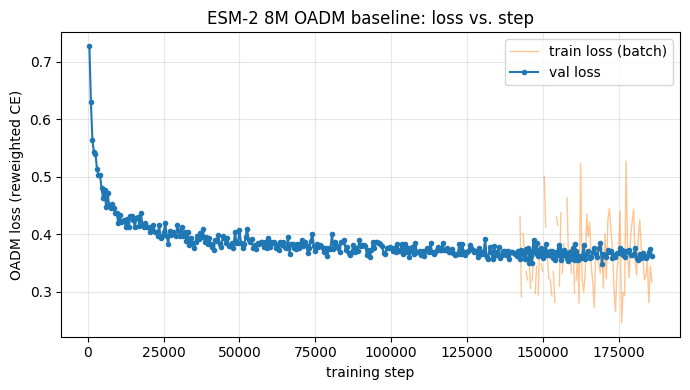

410 logged points | latest val loss = 0.361 | min val loss = 0.348 | plot -> /content/drive/MyDrive/2026 Spring/BMI 702/post_class_project/checkpoints/loss_curve.png


In [16]:
# === Plot the training / validation loss curve ===============================
# Reads the tiny metrics.csv written during training (local if present, else Drive)
# and saves a small PNG to Drive. Safe to run in a fresh session.
import pandas as pd, matplotlib.pyplot as plt

_mp = "/content/ckpt_local/metrics.csv"
if not os.path.exists(_mp):
    _mp = os.path.join(globals().get("CKPT_DIR", "/content/checkpoints"), "metrics.csv")
assert os.path.exists(_mp), f"no metrics.csv yet at {_mp} -- run the training cell first"
dfm = pd.read_csv(_mp).sort_values("step")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dfm["step"], dfm["train_loss"], color="C1", alpha=0.45, lw=1, label="train loss (batch)")
ax.plot(dfm["step"], dfm["val_loss"],   color="C0", marker="o", ms=3,  label="val loss")
ax.set_xlabel("training step"); ax.set_ylabel("OADM loss (reweighted CE)")
ax.set_title("ESM-2 8M OADM baseline: loss vs. step")
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
_png = os.path.join(globals().get("CKPT_DIR", "/content/checkpoints"), "loss_curve.png")
plt.savefig(_png, dpi=120)   # ~tens of KB
plt.show()
print(f"{len(dfm)} logged points | latest val loss = {dfm['val_loss'].iloc[-1]:.3f} "
      f"| min val loss = {dfm['val_loss'].min():.3f} | plot -> {_png}")


## 7. Generation (unconditional baseline)

Reverse OADM process. Start from a fully masked sequence of a length **sampled from the training set**
(`[cls] <mask>×h_len | <mask>×l_len [eos]`), then iteratively unmask. The paper decodes by **minimum entropy** (fill the
most-confident masked position first) rather than a random order. Sampling uses the **temperature** softmax; we restrict
the categorical to the 20 canonical amino acids. Batched: one forward per step over the whole batch.

> **SVDD hook.** This is exactly where the paper's guidance attaches: instead of committing the single chosen token,
> SVDD would expand several candidate "branches", fully denoise each, score with the HIC/AC-SINS predictors, and keep the
> top-scoring branch. Left out here per the baseline-only scope.


In [17]:
@torch.no_grad()
def generate(model, n=16, decoding=None, temperature=None, unmask_per_step=None, seed=None):
    decoding = decoding or cfg.gen_decoding
    temperature = cfg.gen_temperature if temperature is None else temperature
    unmask_per_step = unmask_per_step or cfg.gen_unmask_per_step
    if seed is not None: set_seed(seed)
    model.eval()

    # sample lengths from the empirical training distribution
    chosen = [random.choice(LENGTH_PAIRS) for _ in range(n)]
    rows = []
    for h_len, l_len in chosen:
        ids = [CLS_ID] + [MASK_ID]*h_len + [PIPE_ID] + [MASK_ID]*l_len + [EOS_ID]
        rows.append(ids)
    maxlen = max(len(r) for r in rows)
    input_ids = torch.full((n, maxlen), PAD_ID, dtype=torch.long)
    attn = torch.zeros((n, maxlen), dtype=torch.long)
    for i, r in enumerate(rows):
        input_ids[i, :len(r)] = torch.tensor(r); attn[i, :len(r)] = 1
    input_ids, attn = input_ids.to(DEVICE), attn.to(DEVICE)
    is_masked = (input_ids == MASK_ID)

    aa_ids = AA_IDS.to(DEVICE)
    disallowed = torch.ones(model.config.vocab_size, dtype=torch.bool, device=DEVICE)
    disallowed[aa_ids] = False  # only canonical AAs allowed at generated positions

    steps = int(is_masked.sum(dim=1).max().item())
    for _ in range(steps):
        if not is_masked.any(): break
        raw = model(input_ids=input_ids, attention_mask=attn).logits   # NO temperature here
        raw[:, :, disallowed] = float("-inf")
        # position selection uses the model's native (T=1) confidence
        base = torch.softmax(raw, dim=-1)                              # (N,L,V)
        ent  = -(base * torch.log(base + 1e-12)).sum(dim=-1)           # (N,L)
        ent  = ent.masked_fill(~is_masked, float("inf"))              # only masked positions eligible
        # token sampling uses the temperature-scaled distribution
        sample_probs = torch.softmax(raw / max(temperature, 1e-6), dim=-1)

        for i in range(n):
            mrow = is_masked[i]
            if not mrow.any(): continue
            k = min(unmask_per_step, int(mrow.sum().item()))
            if decoding == "min_entropy":
                pos = torch.topk(ent[i], k, largest=False).indices
            else:  # random order
                cand = torch.nonzero(mrow, as_tuple=False).squeeze(-1)
                pos = cand[torch.randperm(cand.numel(), device=DEVICE)[:k]]
            for p in pos.tolist():
                tok = torch.multinomial(sample_probs[i, p], 1).item()
                input_ids[i, p] = tok
                is_masked[i, p] = False

    out = []
    for i in range(n):
        toks = input_ids[i][attn[i].bool()].tolist()
        s = tokenizer.decode(toks, skip_special_tokens=False)
        # strip specials, split on pipe
        s = s.replace("<cls>", "").replace("<eos>", "").replace("<pad>", "").replace(" ", "")
        if cfg.pipe_token in s:
            h, l = s.split(cfg.pipe_token, 1)
        else:
            h, l = s, ""
        out.append({"heavy": h, "light": l})
    model.train()
    return out

gen = generate(model, n=8, seed=1)
for i, g in enumerate(gen):
    print(f"[{i}] H({len(g['heavy'])}): {g['heavy']}")
    print(f"    L({len(g['light'])}): {g['light']}")

[0] H(123): QVHLQQWGAGLLKPTETLSLTCAVSGGSFSGFRWTWMRQPPGKGLEWIGEINHSGSTNYNPSLKSRVTISVDTSKNQFSLRLTSVTAADTAVYYCASILYYYDSSGPNWFDPWGQGTLVTVSS
    L(108): EIVLTQSPGTLSLSPGERASLSCRASQSVGSNYLVWYQQKPGQAPRLLIYGASNRAIGIPDRFSGSGSGTDFTLTITRLEPEDFGVYYCQQYGRSAWTFGQGTKVEIK
[1] H(130): EVQLVEGGGTLVQPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGPEWVSYISSSSSTIYYADSVKGRFTISRDNAKNSLYLQMNSLRDEDTAVYYCARVLPSSGWFPRFKQTDYSYMDVWGLGTTVTVSS
    L(108): EIVLTQSPGTLSLSPGERATLSCRASQSVSRSYLAWYQQKPGQAPRLLIHGASSRATGIPDRFSGSGSGTDFTLTISRLEPEDFAVYYCQHYGSSLGTFGGGTKVEIK
[2] H(127): QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQATGQGLEWMGGIIPIFGTANYAQKFQGRVTITADESTSTAYMELSSLRSEDTAVYYCARTASIAAAVANYYYYGMDVWGQGTTVTVSS
    L(107): DIQMTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKLLIYAASSLQSGVPSRFSGSGSGTDFTLTISSLQPEDFATYYCQQSYSTPRTFGQGTKLEIK
[3] H(127): EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYAMSWVRQAPGKGLEWVSAISAGGDSTYYADSVKGRFTISRDNSNNTLYLQMNSVRAEDTAVYYCAKDQRSYFGSGNFYYYGMDVWGHGTTVTVSS
    L(108): EIVLTQSPGTLSVSPGERATLSCRASQSVSSSYLAWYQQKPGQAPRLLIYGASNRATGIPDRFSGSG

## 8. Conditional generation / inpainting (optional, for the guided experiments)

OADM makes conditional design trivial: keep template residues fixed, mask the region you want to redesign, and run the
same reverse process. The paper masks either **HCDR3** or the **framework regions** of a GDPa1 template. Below is a
generic helper that masks an explicit index range on the heavy or light chain (use ANARCI/IMGT numbering to get HCDR3
bounds for real templates). SVDD guidance would plug into the same loop as above.


In [ ]:
@torch.no_grad()
def inpaint(model, heavy, light, mask_spans, temperature=None, decoding=None, unmask_per_step=None):
    # mask_spans: list of ('H'|'L', start, end) 0-based half-open ranges to redesign.
    temperature = cfg.gen_temperature if temperature is None else temperature
    decoding = decoding or cfg.gen_decoding
    unmask_per_step = unmask_per_step or cfg.gen_unmask_per_step
    model.eval()
    h = list(heavy); l = list(light)
    seq_ids = [CLS_ID] + tokenizer.convert_tokens_to_ids(h) + [PIPE_ID] \
              + tokenizer.convert_tokens_to_ids(l) + [EOS_ID]
    seq_ids = torch.tensor(seq_ids, dtype=torch.long)
    h_off, l_off = 1, 1 + len(h) + 1  # offsets in the concatenated id sequence
    for chain, s, e in mask_spans:
        base = h_off if chain == "H" else l_off
        seq_ids[base + s: base + e] = MASK_ID
    input_ids = seq_ids.unsqueeze(0).to(DEVICE)
    attn = torch.ones_like(input_ids)
    is_masked = (input_ids == MASK_ID)
    disallowed = torch.ones(model.config.vocab_size, dtype=torch.bool, device=DEVICE)
    disallowed[AA_IDS.to(DEVICE)] = False
    for _ in range(int(is_masked.sum())):
        if not is_masked.any(): break
        raw = model(input_ids=input_ids, attention_mask=attn).logits   # NO temperature here
        raw[:, :, disallowed] = float("-inf")
        base = torch.softmax(raw, -1)                                  # T=1 -> position selection
        ent = -(base * torch.log(base + 1e-12)).sum(-1).masked_fill(~is_masked, float("inf"))
        sample_probs = torch.softmax(raw / max(temperature, 1e-6), -1) # T -> token sampling
        k = min(unmask_per_step, int(is_masked.sum()))
        pos = (torch.topk(ent[0], k, largest=False).indices if decoding == "min_entropy"
               else torch.nonzero(is_masked[0]).squeeze(-1)[:k])
        for p in pos.tolist():
            input_ids[0, p] = torch.multinomial(sample_probs[0, p], 1).item(); is_masked[0, p] = False
    toks = input_ids[0].tolist()
    s = tokenizer.decode(toks, skip_special_tokens=False)
    s = s.replace("<cls>", "").replace("<eos>", "").replace("<pad>", "").replace(" ", "")
    nh, nl = s.split(cfg.pipe_token, 1)
    model.train()
    return nh, nl

# demo: redesign a stretch of the heavy chain of the first training pair
th, tl = train_pairs[0]
nh, nl = inpaint(model, th, tl, [("H", 25, 35)])
print("template H:", th)
print("redesign H:", nh)

## 9. Sanity / baseline metrics

Lightweight checks that mirror the paper's evaluation axes (diversity, plausibility, validity). For full
**naturalness** scoring as in the paper, score `generate()` outputs with **AbLang2** and **p-IgGen** (paired models);
both accept paired H/L sequences. Those packages are heavy, so they're left as an optional add-on.


In [18]:
def aa_composition(seqs):
    c = Counter("".join(seqs))
    tot = sum(c.values()) or 1
    return {a: c.get(a, 0)/tot for a in AA}

def pct_unique(items):
    keys = [g["heavy"] + "|" + g["light"] for g in items]
    return len(set(keys)) / max(len(keys), 1)

def validity(items):
    ok = sum(1 for g in items if g["heavy"] and g["light"]
             and set(g["heavy"]) <= set(AA) and set(g["light"]) <= set(AA))
    return ok / max(len(items), 1)

samples = generate(model, n=64, seed=2)
nat_comp = aa_composition([h + l for h, l in train_pairs])
gen_comp = aa_composition([g["heavy"] + g["light"] for g in samples])
kl = sum(gen_comp[a] * math.log((gen_comp[a] + 1e-9) / (nat_comp[a] + 1e-9)) for a in AA)

print(f"% unique generated : {pct_unique(samples):.3f}")
print(f"% valid (AA-only)  : {validity(samples):.3f}")
print(f"AA-composition KL(gen||train): {kl:.4f}")
gh = np.mean([len(g['heavy']) for g in samples]); gl = np.mean([len(g['light']) for g in samples])
th_ = np.mean([len(h) for h,_ in train_pairs]); tl_ = np.mean([len(l) for _,l in train_pairs])
print(f"mean heavy len gen/train: {gh:.1f}/{th_:.1f} | light: {gl:.1f}/{tl_:.1f}")

% unique generated : 1.000
% valid (AA-only)  : 1.000
AA-composition KL(gen||train): 0.0010
mean heavy len gen/train: 123.0/122.9 | light: 108.3/108.8


In [ ]:
# === Optional: paper-style naturalness with AbLang2 / p-IgGen =================
# Uncomment after installing the packages. These mirror Figure 2b / Figure 5.
#
# import ablang2
# ab = ablang2.pretrained()  # paired model
# samples = generate(model, n=64, seed=3)
# pairs_for_ab = [[g["heavy"], g["light"]] for g in samples]
# loglik = ab(pairs_for_ab, mode="pseudo_log_likelihood")
# print("AbLang2 mean pseudo-loglik:", float(np.mean(loglik)))
print("naturalness scoring stub -- see comment to enable AbLang2 / p-IgGen")

## 10. Save the baseline (shared interface for the DFM comparison)

Save the model, tokenizer, and the training length distribution. When you build the Discrete Flow Matching model,
**reuse the same** `tokenizer`, the same `train_pairs/val_pairs` split, the same `LENGTH_PAIRS` for length sampling, and
the same metric functions (`aa_composition`, `pct_unique`, `validity`, and the AbLang2/p-IgGen naturalness scoring) so the
two models are compared on identical footing. The only thing that changes between baseline and DFM is the
training objective and the sampler — data, tokenizer, and evaluation stay fixed.


In [19]:
SAVE_DIR = "/content/oadm_esm2_8m_baseline"
os.makedirs(SAVE_DIR, exist_ok=True)
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
with open(os.path.join(SAVE_DIR, "length_pairs.json"), "w") as f:
    json.dump(LENGTH_PAIRS, f)
with open(os.path.join(SAVE_DIR, "config.json.bak"), "w") as f:
    json.dump(asdict(cfg), f, indent=2)
print("saved baseline to", SAVE_DIR)
print("files:", os.listdir(SAVE_DIR))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved baseline to /content/oadm_esm2_8m_baseline
files: ['config.json.bak', 'config.json', 'length_pairs.json', 'added_tokens.json', 'vocab.txt', 'model.safetensors', 'tokenizer_config.json']


---
### Notes for scaling to the paper's real setup
- Set `DATA_CSV` to your AntiRef-90 + MMseqs2(0.9)-deduplicated paired-OAS representatives.
- Raise `max_steps` substantially (the paper trains on ~1.68M clusters; this notebook's defaults are smoke-test sized). Adjusted: trained will 2 M
- `gen_temperature ≈ 1.0` was the paper's favorable diversity/naturalness trade-off; sweep `0.5 → 2.0` to reproduce
  Figure 2.
- Keep `gen_decoding="min_entropy"` and `gen_unmask_per_step=1` for faithful OADM decoding; raise the latter only to
  trade fidelity for speed.
- To turn this into the *guided* model, add the SVDD branch-and-score step inside `generate()` using HIC/AC-SINS
  ridge-on-ESM2 predictors — that's the next layer on top of this baseline, not part of it.


In [21]:
import shutil
RELEASE = "/content/drive/MyDrive/2026 Spring/BMI 702/post_class_project/baseline_release"
shutil.copytree(SAVE_DIR, RELEASE, dirs_exist_ok=True)
shutil.make_archive("/content/drive/MyDrive/2026 Spring/BMI 702/post_class_project/baseline_release",
                    "zip", SAVE_DIR)
print("released to Drive:", RELEASE)

released to Drive: /content/drive/MyDrive/2026 Spring/BMI 702/post_class_project/baseline_release
